# Notebook 01 — EDA and Data Cleaning

**Dataset:** LendingClub loans, 2007–2018, ~933K records  
**Targets:** `early_default` (binary), `return` (continuous)  

This notebook covers:
- Dataset overview and schema
- Missing value analysis
- Distributions of key numerical and categorical features
- Correlation analysis
- Target variable analysis (class imbalance, return distribution)

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import load_and_sort, handling_data

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 1. Load and inspect

In [2]:
loan_data = load_and_sort('../data/raw/lc_loan.csv')
print(f'Shape: {loan_data.shape}')
print(f'Date range: {loan_data["issue_d"].min()} to {loan_data["issue_d"].max()}')
loan_data.dtypes

Shape: (933160, 37)
Date range: 2008-01-01 00:00:00 to 2016-12-01 00:00:00


id                                     int64
loan_amnt                            float64
funded_amnt                          float64
int_rate                             float64
installment                          float64
grade                                    str
sub_grade                                str
emp_length                               str
home_ownership                           str
annual_inc                           float64
verification_status                      str
issue_d                       datetime64[us]
loan_status                              str
purpose                                  str
zip_code                                 str
addr_state                               str
dti                                  float64
delinq_2yrs                          float64
earliest_cr_line                         str
fico_range_low                       float64
fico_range_high                      float64
inq_last_6mths                       float64
mths_since

## 2. Missing values

Missing value %:
mths_since_last_delinq    49.754919
emp_length                 6.297741
dtype: float64


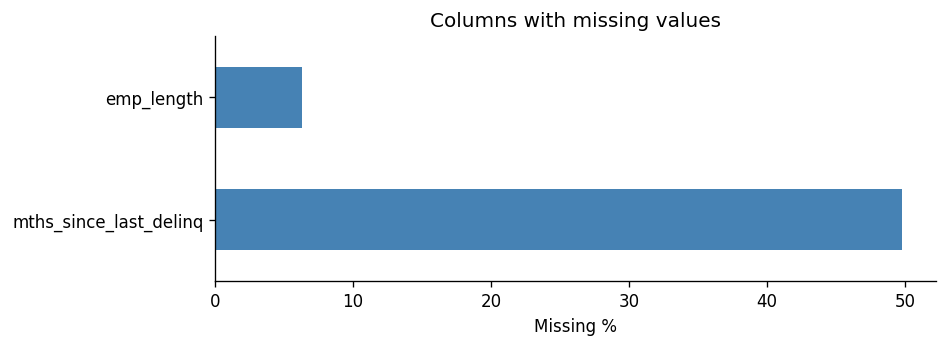

In [3]:
missing = (loan_data.isnull().sum() / len(loan_data) * 100).sort_values(ascending=False)
missing = missing[missing > 0]
print('Missing value %:')
print(missing)

fig, ax = plt.subplots(figsize=(8, 3))
missing.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Missing %')
ax.set_title('Columns with missing values')
plt.tight_layout()
plt.show()

## 3. Summary statistics

In [4]:
key_numerical = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti',
                 'fico_range_low', 'fico_range_high', 'mths_since_last_delinq',
                 'delinq_2yrs', 'revol_bal', 'revol_util']

loan_data[key_numerical].describe().round(2)

,loan_amnt,int_rate,installment,annual_inc,dti,fico_range_low,fico_range_high,mths_since_last_delinq,delinq_2yrs,revol_bal,revol_util
count,933160.00,933160.00,933160.00,933160.00,933160.00,933160.00,933160.00,468867.00,933160.00,933160.00,933160.00
mean,12559.12,0.12,416.32,74122.00,17.83,695.14,699.14,33.97,0.33,15653.39,0.52
std,8042.75,0.04,268.82,69383.99,8.38,31.36,31.36,21.81,0.90,22427.87,0.24
min,500.00,0.05,14.01,3000.00,-1.00,660.00,664.00,0.00,0.00,0.00,0.00
25%,6425.00,0.09,215.63,44000.00,11.52,670.00,674.00,15.00,0.00,5705.00,0.34
50%,10000.00,0.12,339.31,62000.00,17.28,690.00,694.00,31.00,0.00,10496.00,0.53
75%,16275.00,0.14,549.94,90000.00,23.70,710.00,714.00,49.00,0.00,18656.00,0.71
max,40000.00,0.31,1584.90,9573072.00,49.96,845.00,850.00,192.00,30.00,2904836.00,8.92


## 4. Distributions of key features

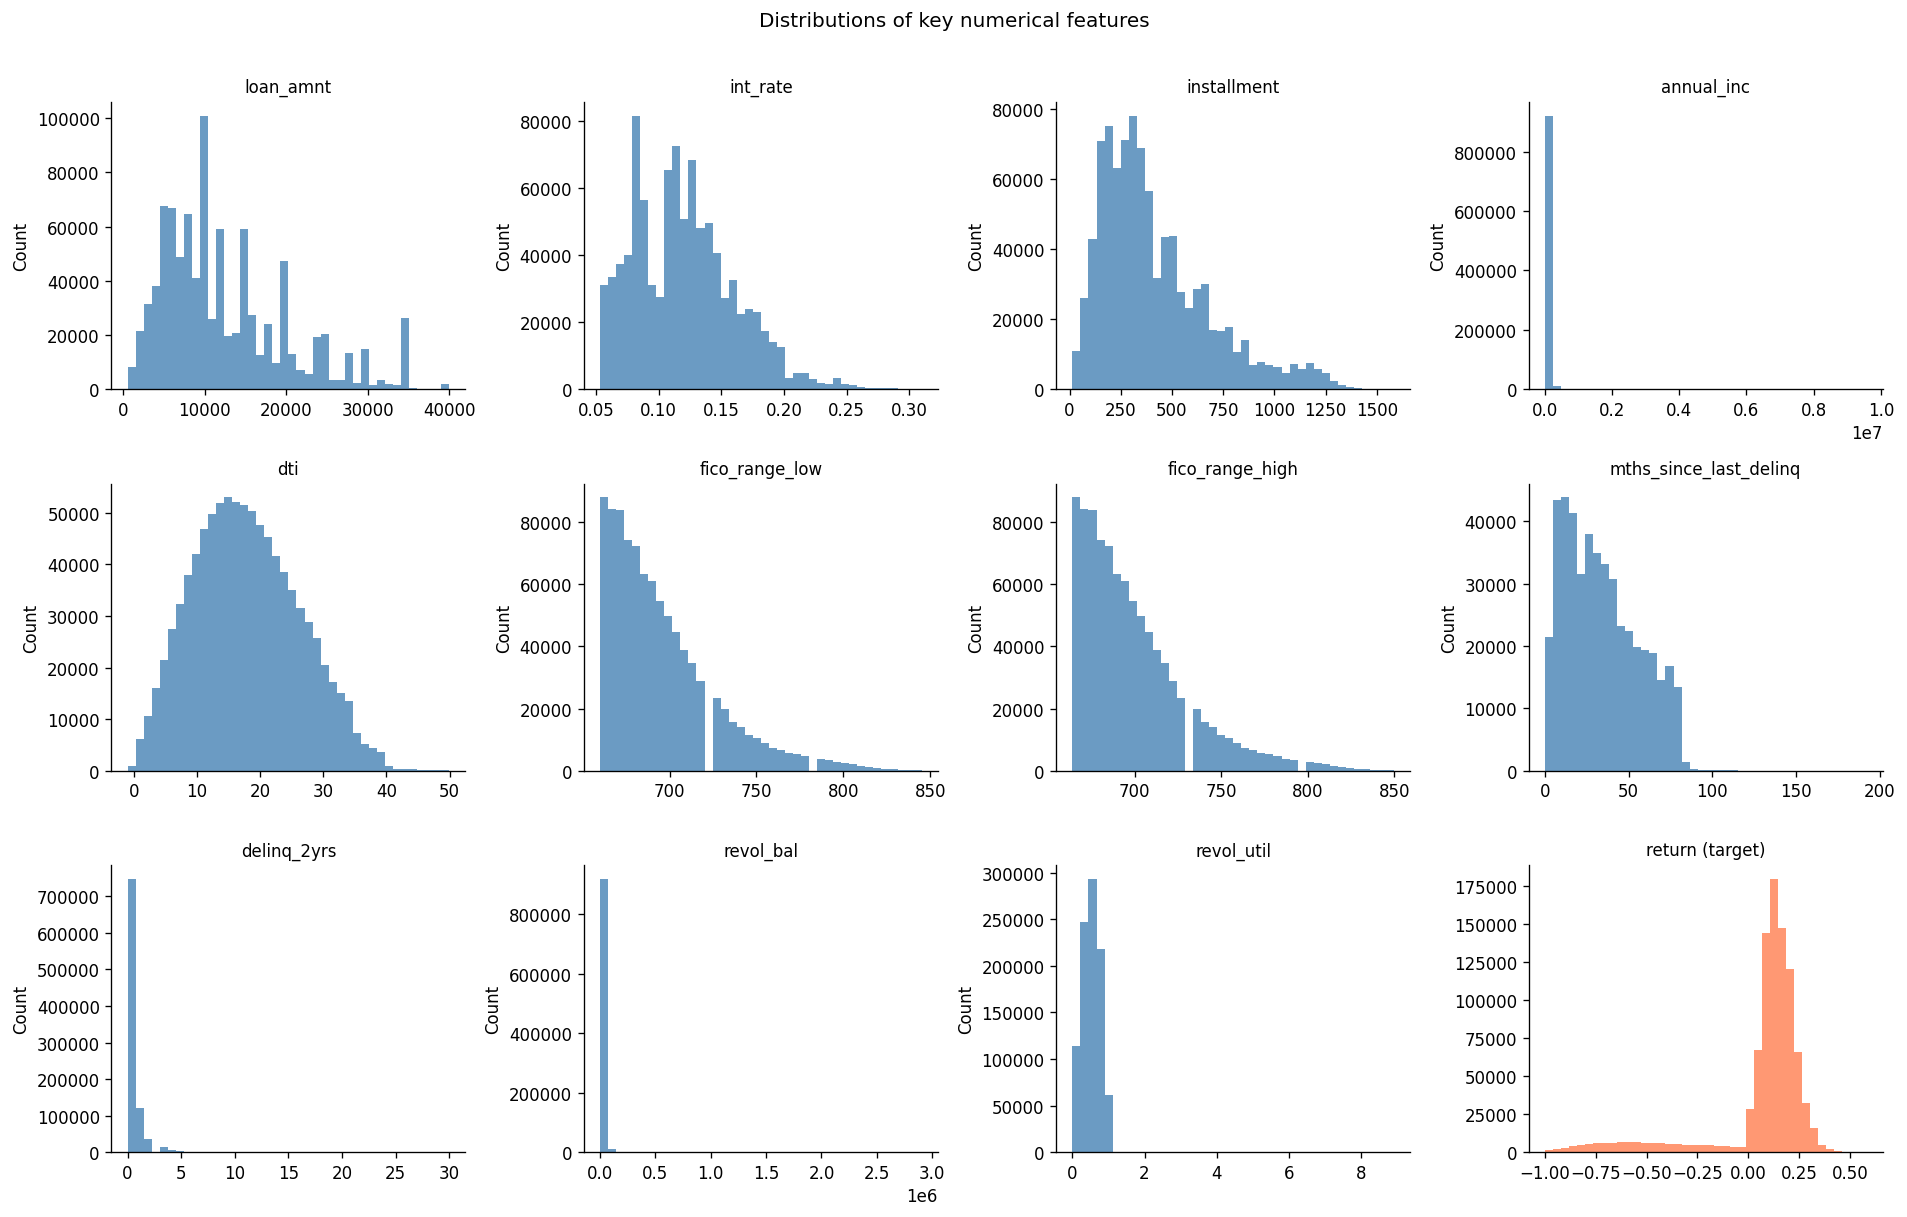

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_numerical):
    data = loan_data[col].dropna()
    axes[i].hist(data, bins=40, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Count')

# Target: return
axes[-1].hist(loan_data['return'].dropna(), bins=40, color='coral', alpha=0.8)
axes[-1].set_title('return (target)', fontsize=10)

plt.suptitle('Distributions of key numerical features', y=1.01)
plt.tight_layout()
plt.show()

## 5. Target variable analysis

Class distribution:
early_default
0    883811
1     49349
Name: count, dtype: int64

Default rate: 5.29%


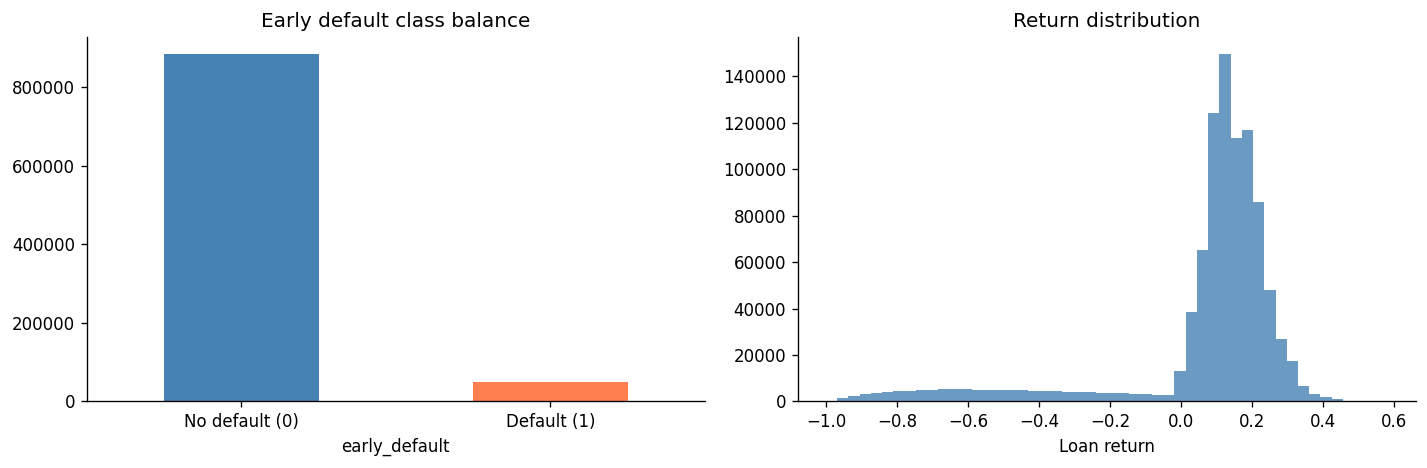

In [6]:
# Class imbalance
default_counts = loan_data['early_default'].value_counts()
print('Class distribution:')
print(default_counts)
print(f'\nDefault rate: {default_counts[1] / len(loan_data):.2%}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

default_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Early default class balance')
axes[0].set_xticklabels(['No default (0)', 'Default (1)'], rotation=0)

axes[1].hist(loan_data['return'], bins=50, color='steelblue', alpha=0.8)
axes[1].set_title('Return distribution')
axes[1].set_xlabel('Loan return')

plt.tight_layout()
plt.show()

## 6. Categorical feature distributions

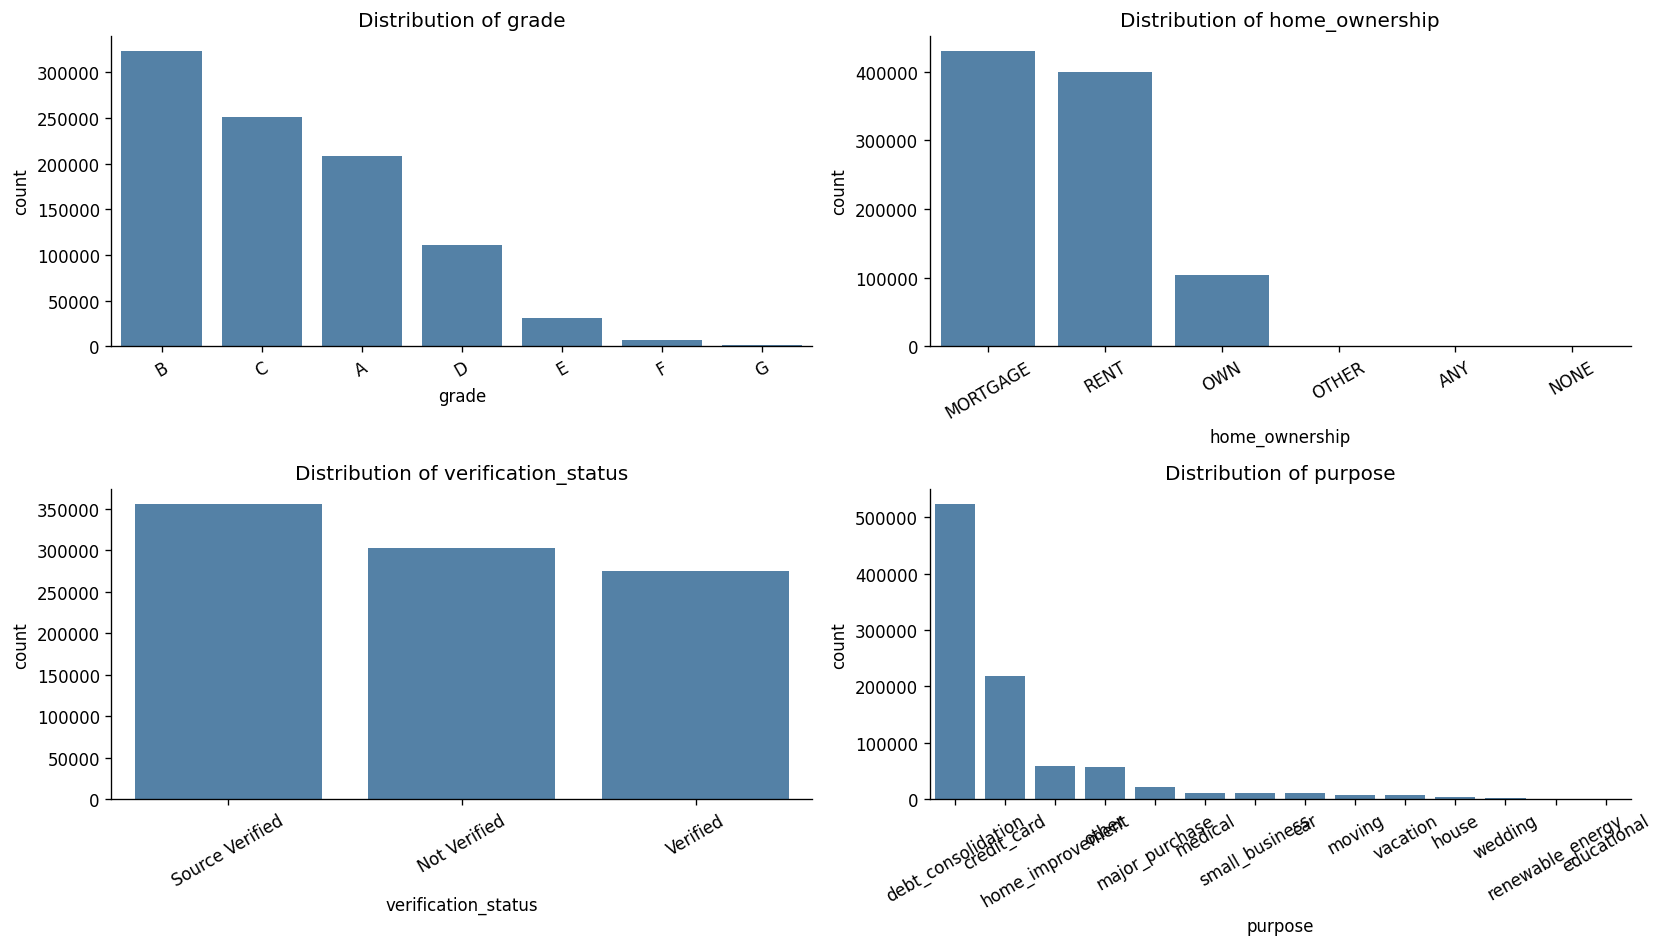

In [7]:
cat_features = ['grade', 'home_ownership', 'verification_status', 'purpose']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    order = loan_data[col].value_counts().index
    sns.countplot(x=col, data=loan_data, order=order, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 7. Correlation heatmap

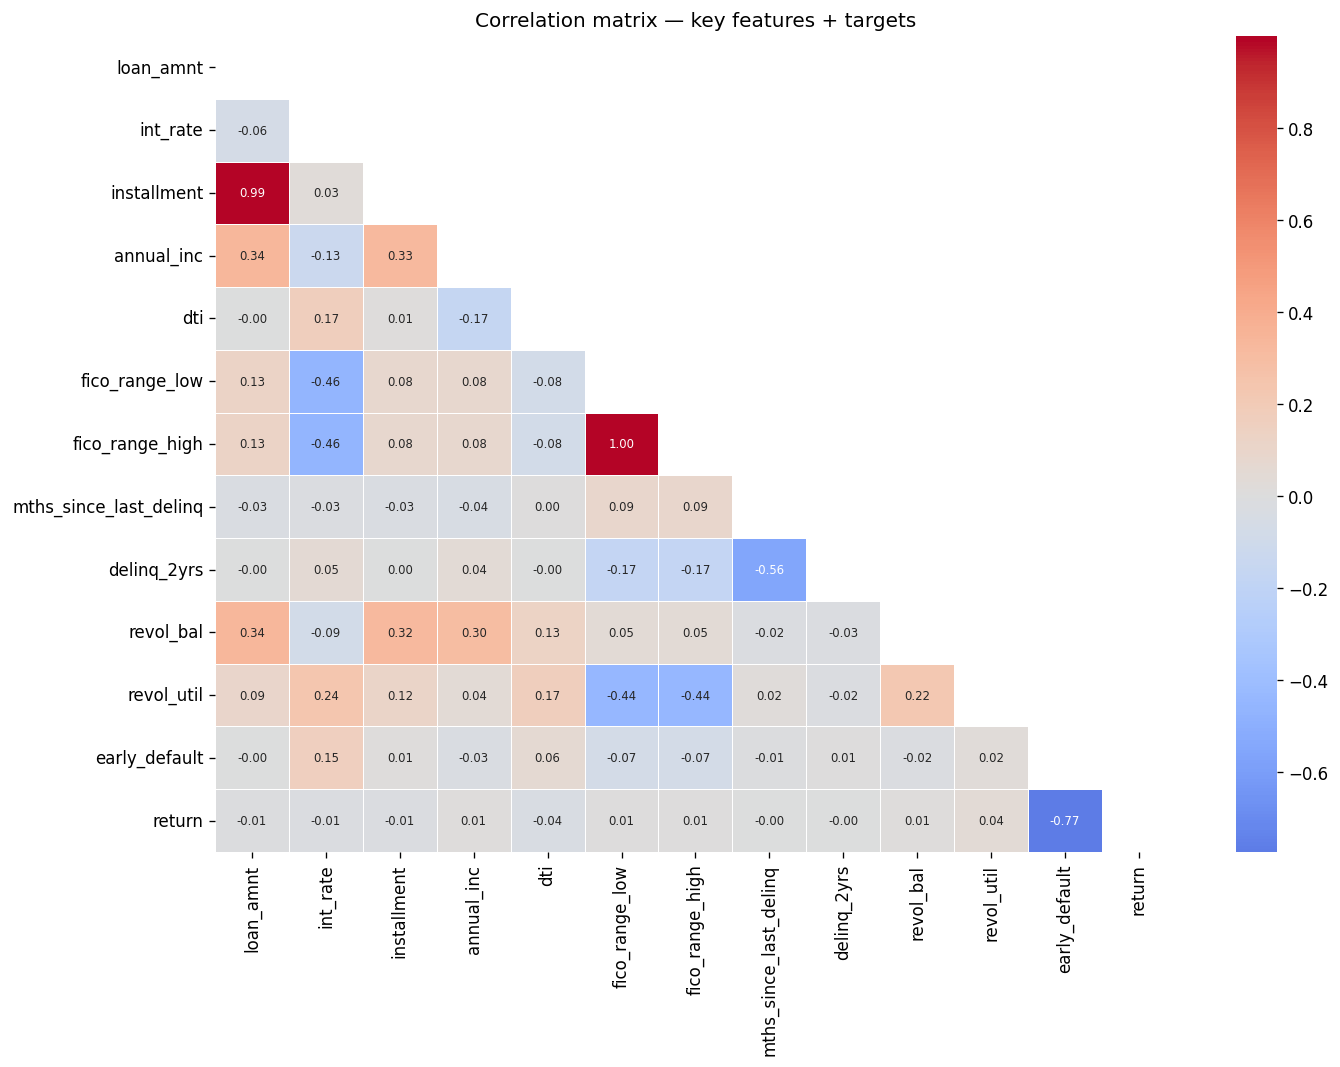

In [8]:
corr_cols = key_numerical + ['early_default', 'return']
corr = loan_data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=ax, linewidths=0.3, annot_kws={'size': 7})
ax.set_title('Correlation matrix — key features + targets')
plt.tight_layout()
plt.show()

## 8. Default rate by loan grade

Key sanity check: default rate should increase as grade degrades (A → G).

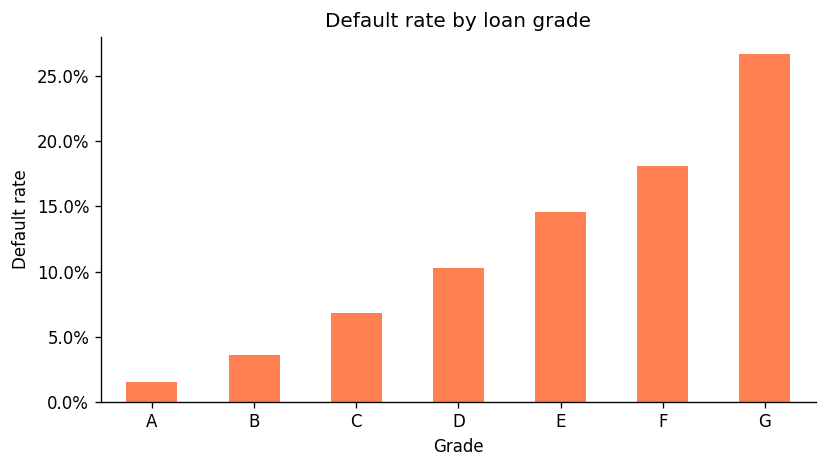


Default rate by grade:
grade
A     1.52%
B     3.59%
C     6.82%
D    10.31%
E    14.55%
F    18.09%
G    26.69%
Name: early_default, dtype: str


In [9]:
grade_default = loan_data.groupby('grade')['early_default'].mean().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
grade_default.plot(kind='bar', ax=ax, color='coral', edgecolor='none')
ax.set_title('Default rate by loan grade')
ax.set_ylabel('Default rate')
ax.set_xlabel('Grade')
ax.tick_params(axis='x', rotation=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
plt.tight_layout()
plt.show()

print('\nDefault rate by grade:')
print(grade_default.map('{:.2%}'.format))

## 9. Loans over time (issue volume)

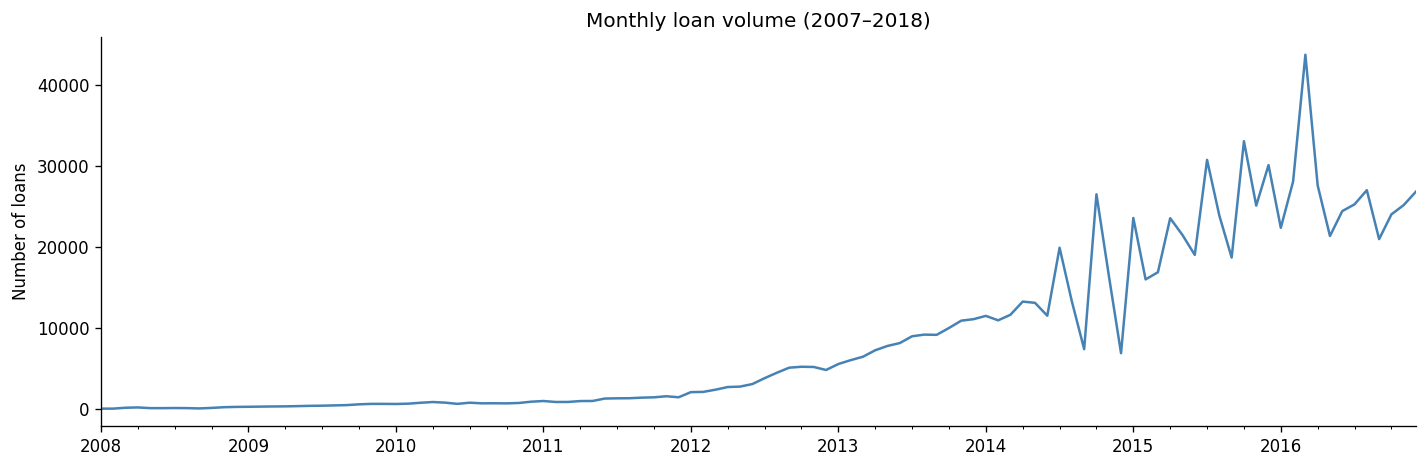

In [10]:
monthly = loan_data.set_index('issue_d').resample('ME')['loan_amnt'].count()

fig, ax = plt.subplots(figsize=(12, 4))
monthly.plot(ax=ax, color='steelblue')
ax.set_title('Monthly loan volume (2007–2018)')
ax.set_ylabel('Number of loans')
ax.set_xlabel('')
plt.tight_layout()
plt.show()